# LUCY — Test con Imágenes Reales
## RT-DETR detecta → SpatialRiskTransformer evalúa → PPO Agent decide

Pasa cualquier imagen y ve qué decide LUCY.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

from engines.rtdetr_detector import RTDetrDetector, COCO_CLASSES, TRAFFIC_CLASS_IDS
from models.spatial_risk_net import SpatialRiskTransformer, RISK_CLASSES, detections_to_tokens
from models.rl_environment    import ActorCritic, ACTIONS, N_ACTIONS, STATE_DIM
from models.behavior_lstm     import BEHAVIOR_CLASSES

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

# ── Cargar detector RT-DETR ──────────────────────────────────────────────────
detector = RTDetrDetector(
    model_path       = 'rtdetr-l.onnx',
    conf_threshold   = 0.35,
    target_class_ids = TRAFFIC_CLASS_IDS,  # person, bike, car, moto, bus, truck, semáforo, stop
)

# ── Cargar SpatialRiskTransformer ────────────────────────────────────────────
spatial_model = SpatialRiskTransformer().to(DEVICE)
spatial_model.load_state_dict(
    torch.load('models/spatial_risk_best.pth', map_location=DEVICE, weights_only=True)
)
spatial_model.eval()

# ── Cargar PPO Agent ─────────────────────────────────────────────────────────
rl_agent = ActorCritic(state_dim=STATE_DIM, n_actions=N_ACTIONS).to(DEVICE)
rl_agent.load_state_dict(
    torch.load('models/rl_agent_best.pth', map_location=DEVICE, weights_only=True)
)
rl_agent.eval()

_ACTION_MAP = {'SAFE': 'MONITOR', 'WARNING': 'WARNING', 'CRITICAL': 'CRITICAL'}
ALERT_COLORS = {
    'MONITOR':  (0, 200, 0),
    'WARNING':  (0, 165, 255),
    'CRITICAL': (0, 0, 255),
}
RISK_COLORS = {
    'SAFE':     '#2ecc71',
    'WARNING':  '#f39c12',
    'CRITICAL': '#e74c3c',
}
COCO_DRAW_COLORS = {
    0:  (255, 178,  50),   # person    → amarillo
    1:  ( 50, 205,  50),   # bicycle   → verde
    2:  ( 50, 120, 255),   # car       → azul
    3:  (180,  50, 255),   # motorcycle→ violeta
    5:  (255,  50,  50),   # bus       → rojo
    7:  (255,  80,   0),   # truck     → naranja
    9:  (  0, 230, 230),   # traffic_light → cyan
    11: (255,   0, 128),   # stop_sign → rosa
}

print('Modelos listos.')

Device: cuda
RTDetrDetector listo
  Modelo:   rtdetr-l.onnx
  Input:    640x640
  Clases:   ['person', 'bicycle', 'car', 'motorcycle', 'bus', 'truck', 'traffic light', 'stop sign']
  Umbral:   0.35
  Backend:  ['CPUExecutionProvider']
Modelos listos.


c:\Users\LENOVO\Documents\Stealth\models\spatial_risk_net.py:132: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)


In [2]:
def lucy_analyze_image(image_path: str, brightness_override: float = None):
    """
    Pipeline completo LUCY sobre una imagen.
    Retorna la imagen anotada + el resultado.
    """
    # 1. Cargar imagen
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise FileNotFoundError(f'No se pudo cargar: {image_path}')
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w    = img_bgr.shape[:2]

    # 2. RT-DETR — detección de objetos
    detections = detector.detect(img_bgr)

    # 3. Normalizar coordenadas a 640x640 para los modelos
    scale_x = 640 / w
    scale_y = 640 / h
    dets_norm = []
    for d in detections:
        b = d['bbox']
        dets_norm.append({
            'class_id':   d['class_id'],
            'bbox':       [b[0]*scale_x, b[1]*scale_y, b[2]*scale_x, b[3]*scale_y],
            'confidence': d['confidence'],
        })

    # 4. SpatialRiskTransformer
    if len(dets_norm) > 0:
        spatial_result = spatial_model.predict(dets_norm, img_w=640, img_h=640)
    else:
        spatial_result = {
            'risk_level': 'SAFE', 'confidence': 0.99,
            'all_probs': {'SAFE': 0.99, 'WARNING': 0.01, 'CRITICAL': 0.0},
            'attention': [],
        }

    # 5. Brillo real de la imagen
    brightness = brightness_override or float(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY).mean())

    # 6. PPO RL Agent
    r_probs = np.array([spatial_result['all_probs'][c] for c in RISK_CLASSES], dtype=np.float32)
    state   = np.zeros(STATE_DIM, dtype=np.float32)
    state[6:9] = r_probs
    state[10]  = r_probs[2]          # P(CRITICAL)
    state[11]  = r_probs[1]          # P(WARNING)
    state[13]  = r_probs[0]          # P(SAFE)
    state[14]  = brightness / 255.0
    with torch.no_grad():
        action, _, _ = rl_agent.act(state, deterministic=True)
    lucy_action = _ACTION_MAP[ACTIONS[action]]

    # 7. Anotar imagen
    annotated = img_rgb.copy()
    attn_vals = spatial_result.get('attention', [])

    for i, d in enumerate(detections):
        x1, y1, x2, y2 = d['bbox']
        cls   = d['class_id']
        name  = d['class_name']
        conf  = d['confidence']
        color = COCO_DRAW_COLORS.get(cls, (200, 200, 200))

        # Grosor proporcional a la atención
        attn_w = attn_vals[i] if i < len(attn_vals) else 0.0
        thick  = max(2, int(2 + attn_w * 12))

        cv2.rectangle(annotated, (x1, y1), (x2, y2), color, thick)

        label = f'{name} {conf:.2f}'
        if i < len(attn_vals):
            label += f' | attn:{attn_vals[i]*100:.0f}%'

        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 1)
        cv2.rectangle(annotated, (x1, y1 - th - 6), (x1 + tw + 4, y1), color, -1)
        cv2.putText(annotated, label, (x1 + 2, y1 - 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 0), 1, cv2.LINE_AA)

    # Banner LUCY en la parte superior
    alert_bgr = ALERT_COLORS[lucy_action]
    banner_h  = 50
    cv2.rectangle(annotated, (0, 0), (w, banner_h), alert_bgr[::-1], -1)
    banner_txt = f'LUCY: {lucy_action}  |  Riesgo: {spatial_result["risk_level"]}  |  Objetos: {len(detections)}  |  Brillo: {brightness:.0f}'
    cv2.putText(annotated, banner_txt, (10, 33),
                cv2.FONT_HERSHEY_SIMPLEX, 0.75, (255, 255, 255), 2, cv2.LINE_AA)

    return annotated, {
        'detections':     detections,
        'spatial_result': spatial_result,
        'lucy_action':    lucy_action,
        'brightness':     brightness,
        'n_objects':      len(detections),
    }

print('Función lucy_analyze_image lista.')

Función lucy_analyze_image lista.


## Todas las imágenes de test_images/

In [3]:
import glob

image_paths = sorted(
    glob.glob('test_images/*.jpg') +
    glob.glob('test_images/*.png') +
    glob.glob('test_images/*.MP4')  # excluir videos
)
# Filtrar solo imágenes
image_paths = [p for p in image_paths if p.lower().endswith(('.jpg','.jpeg','.png'))]

print(f'Imágenes encontradas: {len(image_paths)}')
for p in image_paths:
    print(f'  {p}')

Imágenes encontradas: 6
  test_images\calle1.jpg
  test_images\calle2.jpg
  test_images\calle3.png
  test_images\calle3oscura.jpg
  test_images\prueba1.jpg
  test_images\pruebasospechosa.jpg


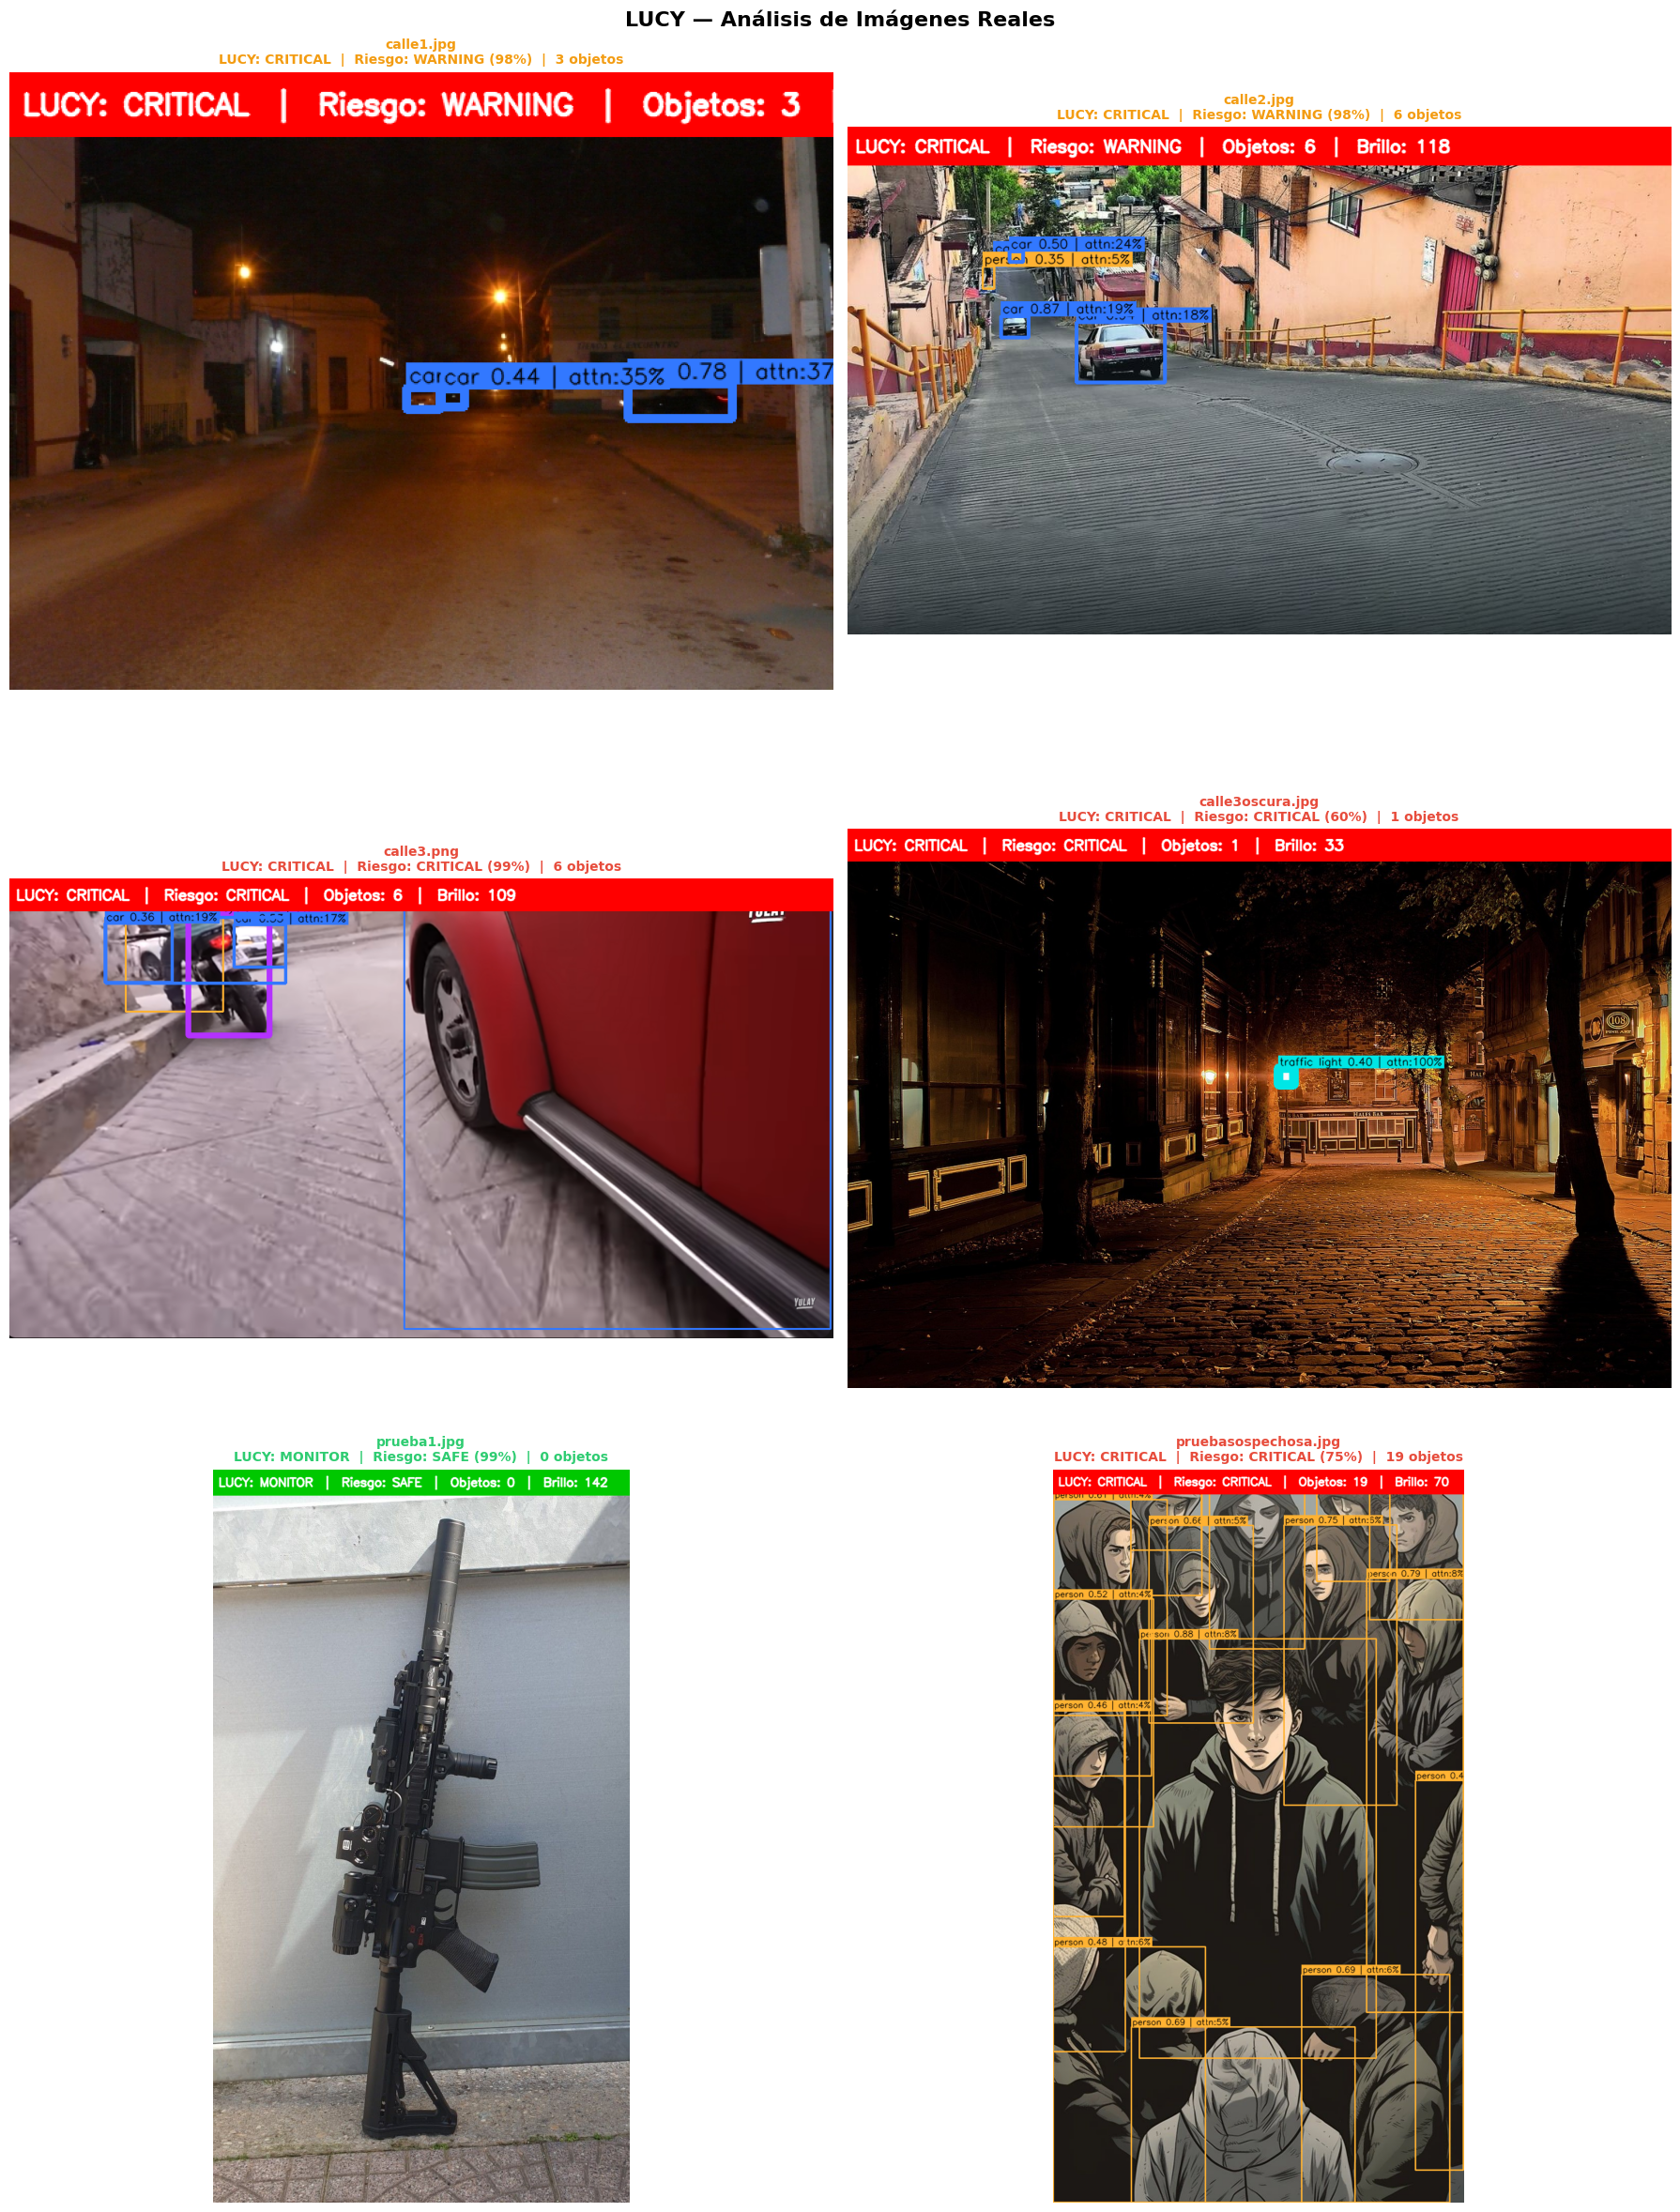

In [4]:
# Procesar todas las imágenes
results_all = []

cols = 2
rows = (len(image_paths) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(18, 8 * rows))
fig.suptitle('LUCY — Análisis de Imágenes Reales', fontsize=16, fontweight='bold')

if rows == 1:
    axes = [axes] if cols == 1 else [axes]
axes_flat = [ax for row in axes for ax in (row if hasattr(row, '__iter__') else [row])]

for i, path in enumerate(image_paths):
    ax = axes_flat[i]
    try:
        annotated, result = lucy_analyze_image(path)
        results_all.append({'path': path, **result})

        ax.imshow(annotated)
        ax.axis('off')

        risk_color = RISK_COLORS[result['spatial_result']['risk_level']]
        ax.set_title(
            f"{Path(path).name}\n"
            f"LUCY: {result['lucy_action']}  |  "
            f"Riesgo: {result['spatial_result']['risk_level']} "
            f"({result['spatial_result']['confidence']*100:.0f}%)  |  "
            f"{result['n_objects']} objetos",
            fontsize=10, color=risk_color, fontweight='bold'
        )
    except Exception as e:
        ax.text(0.5, 0.5, f'Error:\n{e}', ha='center', va='center',
                transform=ax.transAxes, fontsize=10, color='red')
        ax.axis('off')

# Ocultar ejes sobrantes
for j in range(len(image_paths), len(axes_flat)):
    axes_flat[j].axis('off')

plt.tight_layout()
plt.savefig('output/test_imagenes_reales.png', dpi=120, bbox_inches='tight')
plt.show()

## Resumen de resultados

In [5]:
print(f'{'Imagen':<30} {'Objetos':>8} {'Riesgo':>10} {'Conf':>7} {'LUCY':>10} {'Brillo':>8}')
print('-' * 78)
for r in results_all:
    print(
        f"{Path(r['path']).name:<30}"
        f"{r['n_objects']:>8}"
        f"{r['spatial_result']['risk_level']:>10}"
        f"{r['spatial_result']['confidence']*100:>6.0f}%"
        f"{r['lucy_action']:>10}"
        f"{r['brightness']:>8.0f}"
    )

Imagen                          Objetos     Riesgo    Conf       LUCY   Brillo
------------------------------------------------------------------------------
calle1.jpg                           3   WARNING    98%  CRITICAL      46
calle2.jpg                           6   WARNING    98%  CRITICAL     118
calle3.png                           6  CRITICAL    99%  CRITICAL     109
calle3oscura.jpg                     1  CRITICAL    60%  CRITICAL      33
prueba1.jpg                          0      SAFE    99%   MONITOR     142
pruebasospechosa.jpg                19  CRITICAL    75%  CRITICAL      70


## Probar con cualquier imagen propia

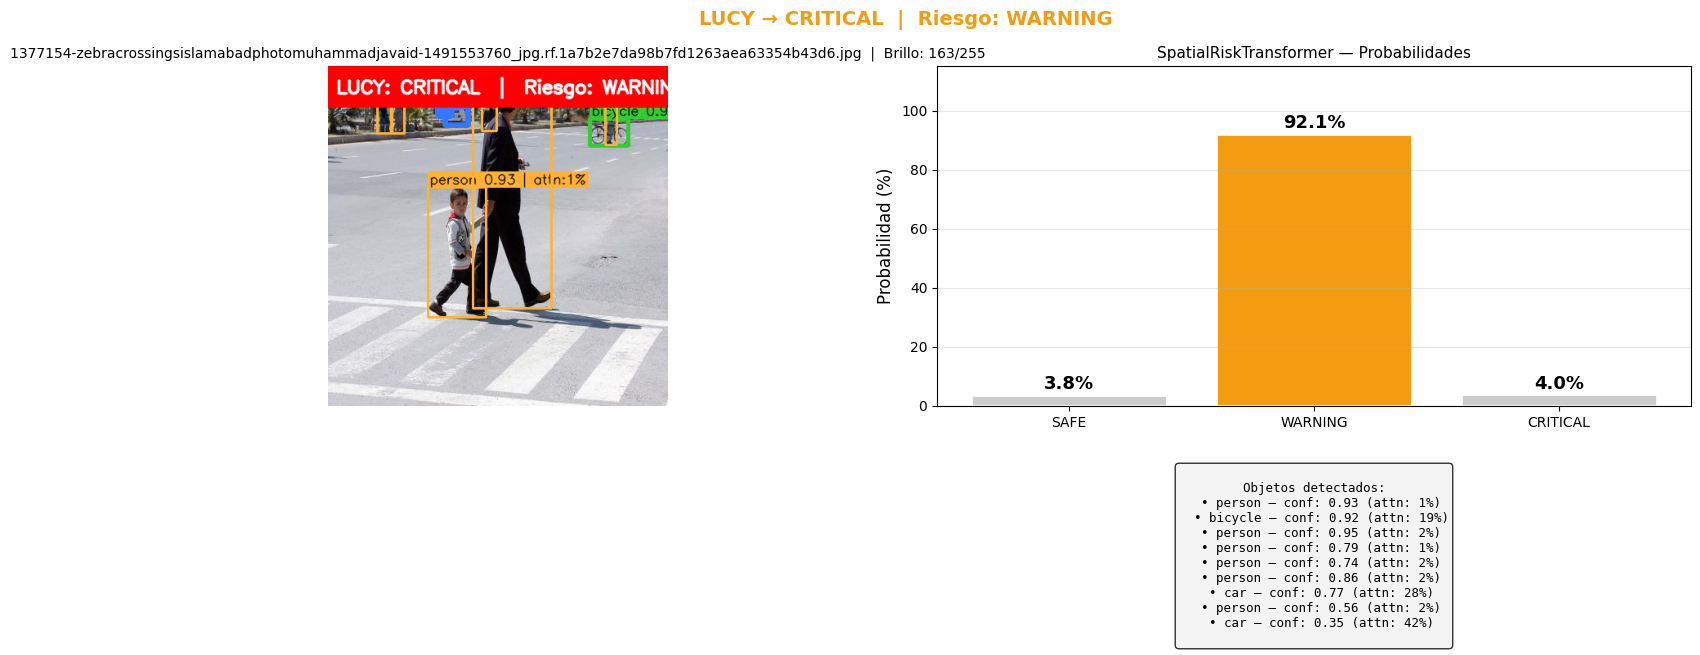


Detecciones:
  person          conf=0.93  bbox=[122, 148, 193, 307]
  bicycle         conf=0.92  bbox=[320, 64, 367, 97]
  person          conf=0.95  bbox=[177, 22, 273, 296]
  person          conf=0.79  bbox=[60, 32, 77, 82]
  person          conf=0.74  bbox=[188, 40, 206, 79]
  person          conf=0.86  bbox=[339, 45, 353, 96]
  car             conf=0.77  bbox=[143, 49, 171, 72]
  person          conf=0.56  bbox=[78, 32, 93, 82]
  car             conf=0.35  bbox=[135, 47, 150, 60]


In [11]:
# ← CAMBIA ESTA RUTA por cualquier imagen que quieras probar
MI_IMAGEN = r'C:\Users\LENOVO\Documents\Stealth\datasets\pedestrian_detection\valid\images\1377154-zebracrossingsislamabadphotomuhammadjavaid-1491553760_jpg.rf.1a7b2e7da98b7fd1263aea63354b43d6.jpg'

annotated, result = lucy_analyze_image(MI_IMAGEN)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
risk_color = RISK_COLORS[result['spatial_result']['risk_level']]
fig.suptitle(
    f"LUCY → {result['lucy_action']}  |  Riesgo: {result['spatial_result']['risk_level']}",
    fontsize=14, fontweight='bold', color=risk_color
)

# Imagen anotada
axes[0].imshow(annotated)
axes[0].axis('off')
axes[0].set_title(f"{Path(MI_IMAGEN).name}  |  Brillo: {result['brightness']:.0f}/255", fontsize=10)

# Probabilidades de riesgo
ax = axes[1]
probs     = [result['spatial_result']['all_probs'][c] for c in RISK_CLASSES]
bar_cols  = [RISK_COLORS[c] for c in RISK_CLASSES]
highlight = [c if RISK_CLASSES[i] == result['spatial_result']['risk_level'] else '#cccccc'
             for i, c in enumerate(bar_cols)]
bars = ax.bar(RISK_CLASSES, [p*100 for p in probs], color=highlight,
              edgecolor='white', linewidth=2)
for bar, p in zip(bars, probs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{p*100:.1f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')

# Objetos detectados
if result['detections']:
    attn = result['spatial_result'].get('attention', [])
    det_txt = '\nObjetos detectados:\n'
    for j, d in enumerate(result['detections']):
        a_str = f" (attn: {attn[j]*100:.0f}%)" if j < len(attn) else ''
        det_txt += f"  • {d['class_name']} — conf: {d['confidence']:.2f}{a_str}\n"
    ax.text(0.5, -0.18, det_txt, transform=ax.transAxes,
            ha='center', va='top', fontsize=9, family='monospace',
            bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.8))

ax.set_ylabel('Probabilidad (%)', fontsize=12)
ax.set_title('SpatialRiskTransformer — Probabilidades', fontsize=11)
ax.set_ylim(0, 115)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('output/lucy_mi_imagen.png', dpi=130, bbox_inches='tight')
plt.show()

print(f'\nDetecciones:')
for d in result['detections']:
    print(f"  {d['class_name']:<15} conf={d['confidence']:.2f}  bbox={d['bbox']}")